In [19]:
import sys
import os

import pandas as pd
import scanpy as sc
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.pyplot import rc_context
import anndata
import seaborn as sns
import torch
import matplotlib.font_manager
from matplotlib import rcParams
from scipy.stats import pearsonr
rcParams.update({'font.size': 10})
rcParams.update({'figure.dpi': 300})
rcParams.update({'figure.figsize': (3,3)})
rcParams.update({'savefig.dpi': 500})

In [20]:
%load_ext autoreload
%autoreload 2

sys.path.append('../Squidiff/')
import sample_squidiff

# import plot_util ## the custom plot_util file is completely missing in the code base

import warnings
warnings.filterwarnings('ignore')

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [21]:
sampler = sample_squidiff.sampler(
    model_path = '/projectnb/ds596/projects/Team 8/checkpoint/diff_data/model.pt', #'diff_results/model.pt',
    gene_size = 203,
    output_dim = 203,
    use_drug_structure = False
)

load model and diffusion...
diffusion num of steps =  1000


In [22]:
!nvcc --version

nvcc: NVIDIA (R) Cuda compiler driver
Copyright (c) 2005-2025 NVIDIA Corporation
Built on Wed_Jan_15_19:20:09_PST_2025
Cuda compilation tools, release 12.8, V12.8.61
Build cuda_12.8.r12.8/compiler.35404655_0


In [23]:
print(f"CUDA available: {torch.cuda.is_available()}")
print(torch.version.cuda) 

CUDA available: True
12.8


In [24]:
train_adata = sc.read_h5ad('/projectnb/ds596/projects/Team 8/data/diff_data_fig2/diff_train.h5ad')
z_sem = sampler.model.encoder(
    torch.tensor(train_adata.X).to('cuda')
)

scrnas_pred = sampler.pred(z_sem, gene_size = train_adata.shape[1])
                
x_T = sampler.stochastic_encode(
    sampler.model,
    x = torch.tensor(train_adata.X, dtype = torch.float32).to('cuda'),
    t = 999,
    model_kwargs={'x_start':torch.tensor(train_adata.X, dtype = torch.float32).to('cuda'),
                  'z_mod':z_sem,
    }
)['sample']

In [25]:
z_sem

tensor([[ 0.7666,  0.5031, -0.2296,  ..., -0.4272,  0.5715, -0.4932],
        [ 0.2821, -0.4257, -0.1305,  ..., -0.0461, -0.8166,  0.6454],
        [ 0.0791, -0.2982,  0.5130,  ...,  0.0670,  0.7895,  0.4309],
        ...,
        [-0.6023,  0.0415,  0.1772,  ...,  0.1727,  0.4242,  0.5216],
        [ 0.4304,  0.2774,  0.2473,  ..., -0.0074,  0.4786,  0.1305],
        [ 0.0390,  0.5216, -0.5322,  ..., -0.3068, -0.4674, -0.4643]],
       device='cuda:0', grad_fn=<AddmmBackward0>)

In [8]:
sc.pl.pca(z_sem,
                   label = train_adata.obs['Group'],
                   size = 3, alpha=0.8,
                   colorlist = ['#3145a8', '#fa2616'],
                   color_label=[0,3]
                  )

AttributeError: 'Tensor' object has no attribute '_sanitize'

In [ ]:
plot_util.plot_pca(x_T,
                   label = train_adata.obs['Group'],
                   size = 3, alpha=0.8,
                   colorlist = ['#3145a8', '#fa2616'],
                   color_label=[0,3]
                  )

## predict day 1-3 from day 0 and direction 

In [26]:
# get the day 0 vector from test data
z_sem = sampler.model.encoder(torch.tensor(train_adata.X).to('cuda'))
# get the represented differentiation latent vector  
direct_z_sem = z_sem[train_adata.obs.Group==3].mean(axis=0) - z_sem[train_adata.obs.Group==0].mean(axis=0)

In [27]:
test_adata = sc.read_h5ad('/projectnb/ds596/projects/Team 8/data/diff_data_fig2/diff_test.h5ad')
z_sem_test_day0 = sampler.model.encoder(torch.tensor(test_adata[test_adata.obs['Group']==0].X).to('cuda'))
z_sem_test_day3 = sampler.model.encoder(torch.tensor(test_adata[test_adata.obs['Group']==3].X).to('cuda'))


In [28]:
z_sem_test_day0.shape

torch.Size([600, 60])

In [29]:
r_all = []
pearsonr_all = []

for i in range(6):
    sample_interp0 = sampler.pred(z_sem = z_sem_test_day0,
                                  gene_size = 203,
                                 )
    sample_interp1 = sampler.interp_with_direction(z_sem_origin = z_sem_test_day0,
                                                   gene_size = 203,
                                                   direction = direct_z_sem,
                                                   scale = 1/3
                                                  )
    sample_interp2 = sampler.interp_with_direction(z_sem_origin = z_sem_test_day0,
                                                   gene_size = 203,
                                                   direction = direct_z_sem,
                                                   scale = 2/3
                                                  )
    sample_interp3 = sampler.pred(z_sem = z_sem_test_day3,
                                  gene_size = 203,
                                 )
    r2_, pearsonr_ = sampler.cal_metric(sample_interp0, test_adata[test_adata.obs['Group']==0])
    r_all.append(['squidiff',i,'day0',r2_])
    pearsonr_all.append(['squidiff',i,'day0',pearsonr_])
    r2_, pearsonr_ = sampler.cal_metric(sample_interp1, test_adata[test_adata.obs['Group']==1])
    r_all.append(['squidiff',i,'day1',r2_])
    pearsonr_all.append(['squidiff',i,'day1',pearsonr_])
    r2_, pearsonr_ = sampler.cal_metric(sample_interp2,  test_adata[test_adata.obs['Group']==2])
    r_all.append(['squidiff',i,'day2',r2_])
    pearsonr_all.append(['squidiff',i,'day2',pearsonr_])
    r2_, pearsonr_ = sampler.cal_metric(sample_interp3, test_adata[test_adata.obs['Group']==3])
    r_all.append(['squidiff',i,'day3',r2_])
    pearsonr_all.append(['squidiff',i,'day3',pearsonr_])
    
# pd.DataFrame(r_all).to_csv('/hpc/mydata/siyu.he/Siyu_projects/Squidiff_reproducibility/fig2_diff_r_all_new.csv')
# pd.DataFrame(pearsonr_all).to_csv('/hpc/mydata/siyu.he/Siyu_projects/Squidiff_reproducibility/fig2_diff_pearsonr_all_new.csv')


In [30]:
z_sem_test_day1 = sampler.model.encoder(torch.tensor(sample_interp1).to('cuda'))
direct_z_sem_d1 = z_sem[train_adata.obs.Group==3].mean(axis=0) - z_sem_test_day1.mean(axis=0)
sample_interp4 = sampler.interp_with_direction(z_sem_origin = z_sem_test_day1,
                                                   gene_size = 203,
                                                   direction = direct_z_sem_d1,
                                                   scale = 1/2)

Text(0.1, 0.9, 'Pearsonr= 0.900')

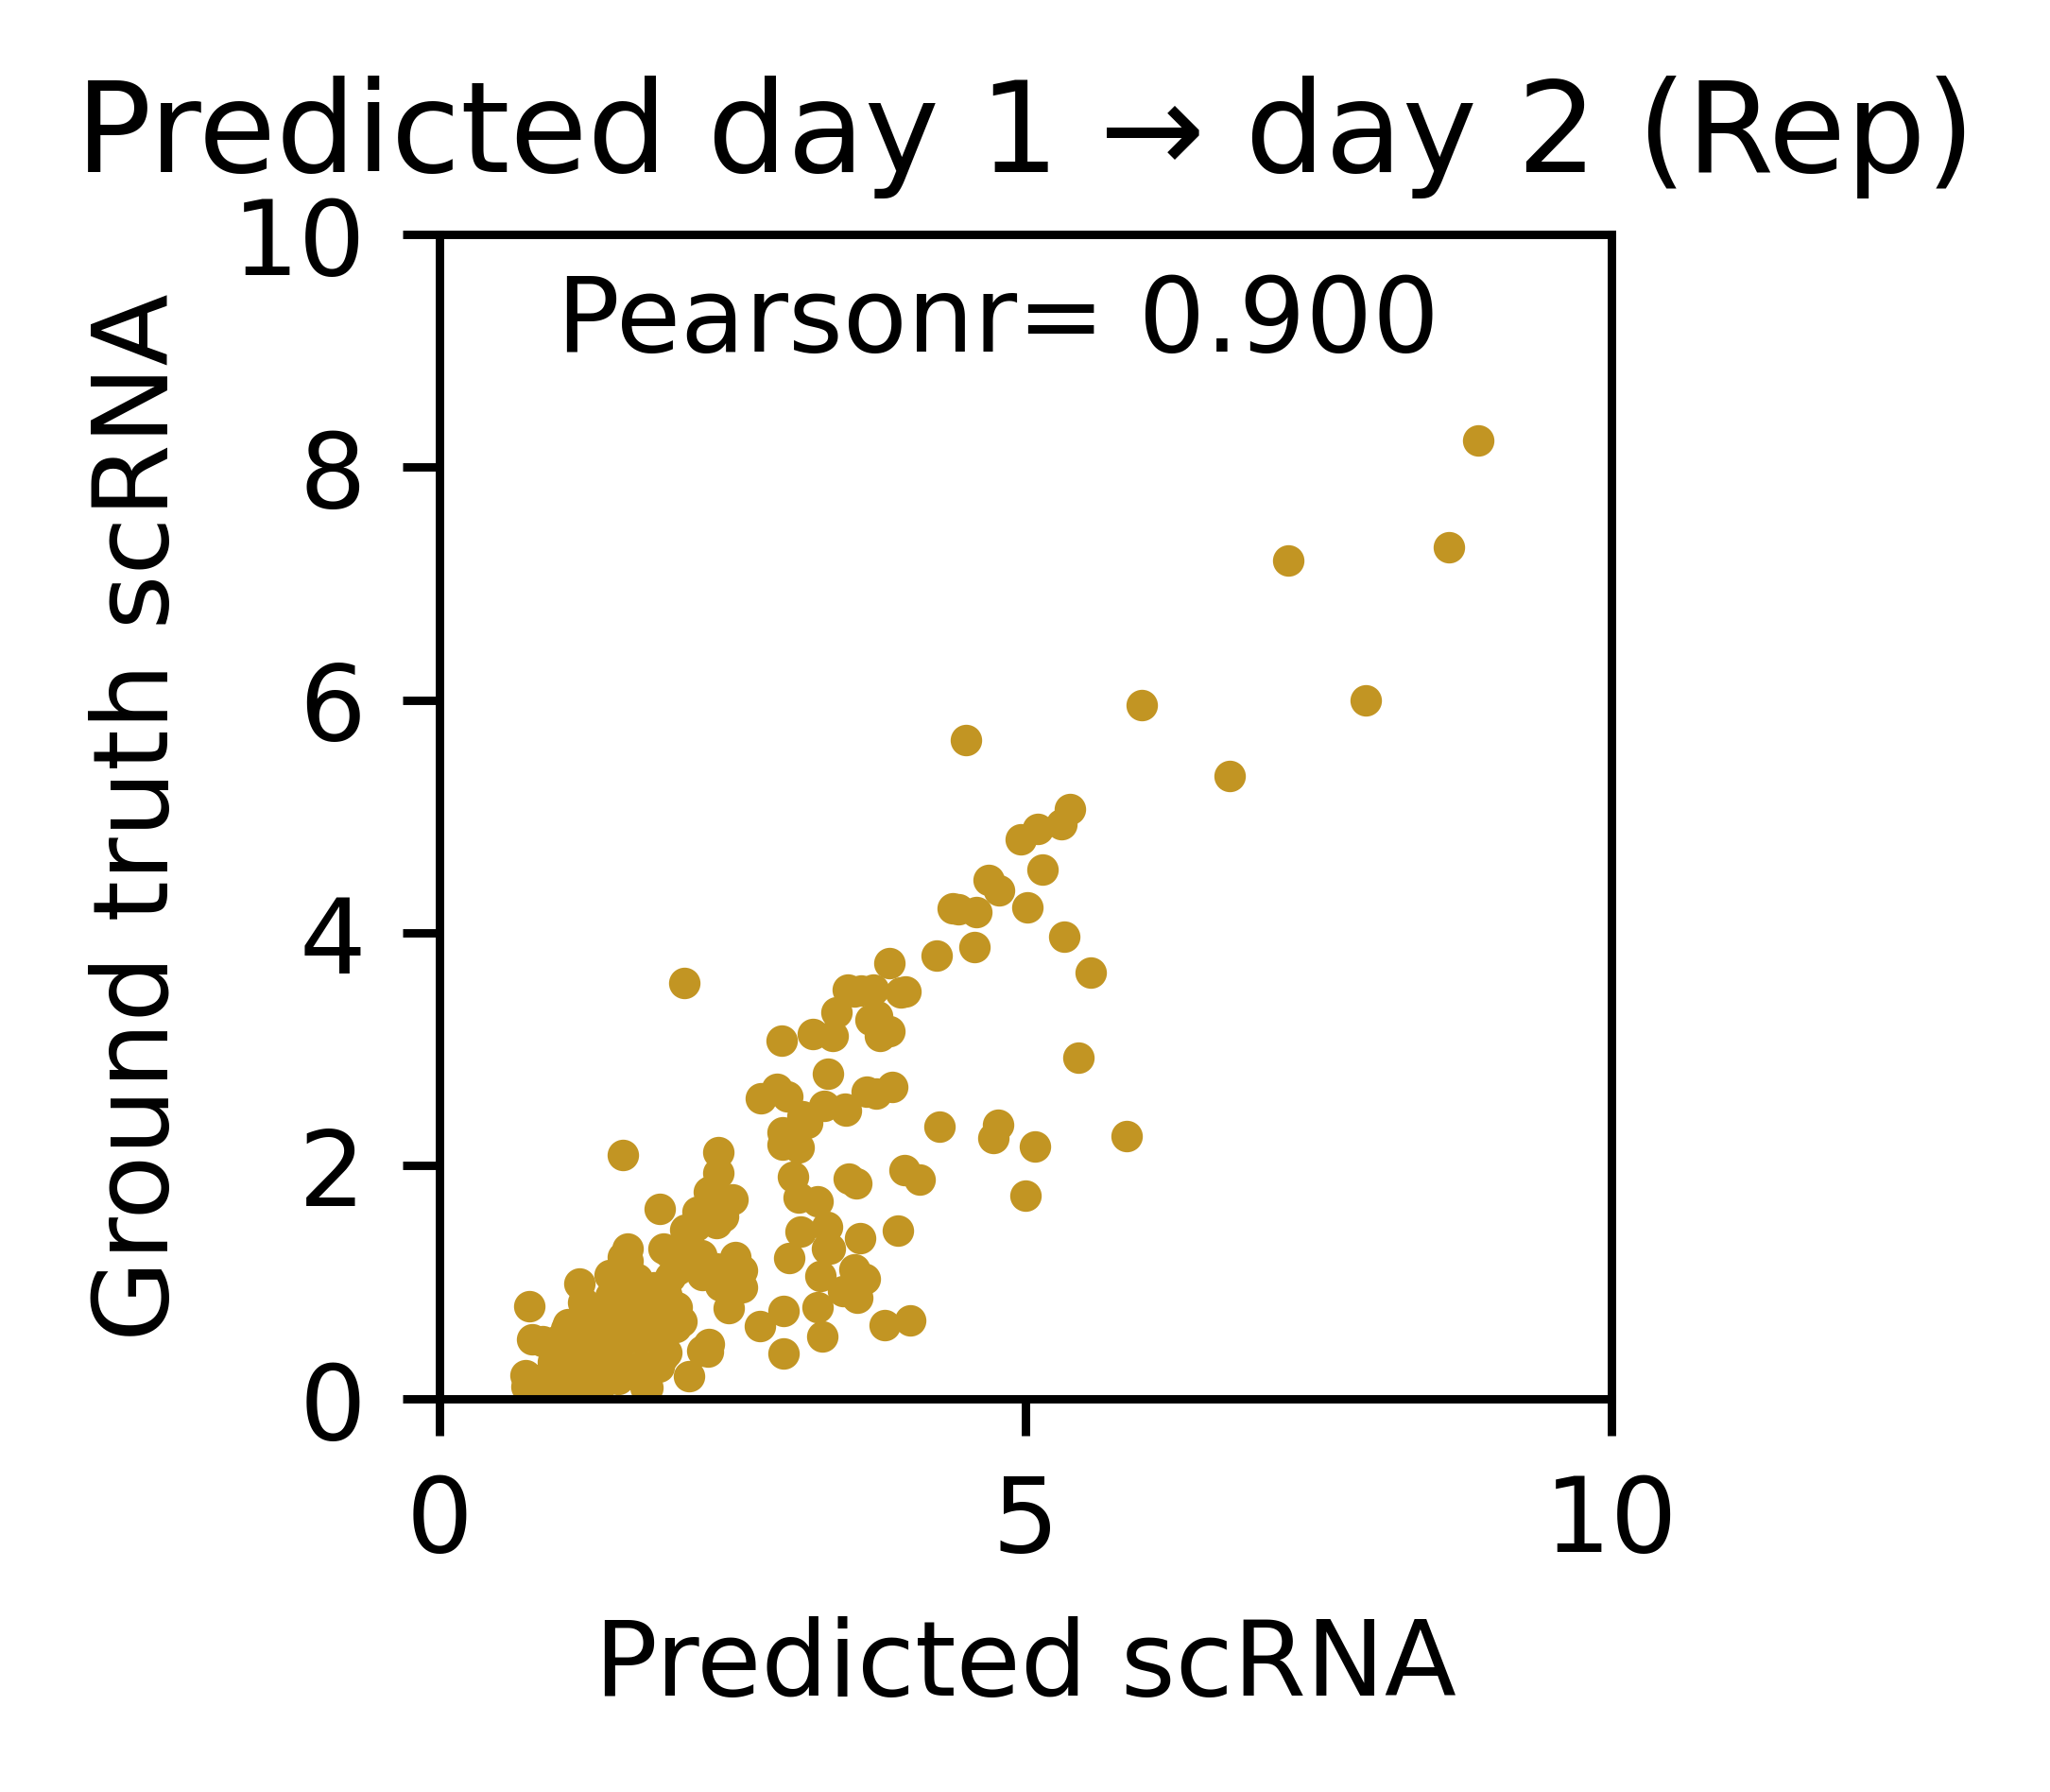

In [31]:
# d1 -> d2
plt.subplots(1,1,figsize=(2,2),dpi=800)
plt.scatter(sample_interp4.detach().cpu().mean(axis=0),
            test_adata[test_adata.obs['Group']==2].X.mean(axis=0),
            s=4,
            c='#c29523'
           )
plt.xlim([0,10])
plt.ylim([0,10])
plt.xlabel('Predicted scRNA')
plt.ylabel('Ground truth scRNA')
plt.title('Predicted day 1 → day 2 (Rep)')
sampler.cal_metric(sample_interp4, test_adata[test_adata.obs['Group']==2])
# add person correlation coefficient in the plot
r, p = pearsonr(sample_interp4.detach().cpu().mean(axis=0), test_adata[test_adata.obs['Group']==2].X.mean(axis=0))
plt.text(0.1, 0.9, f'Pearsonr= {r:.3f}', transform=plt.gca().transAxes)

Text(0.1, 0.9, 'Pearsonr= 0.920')

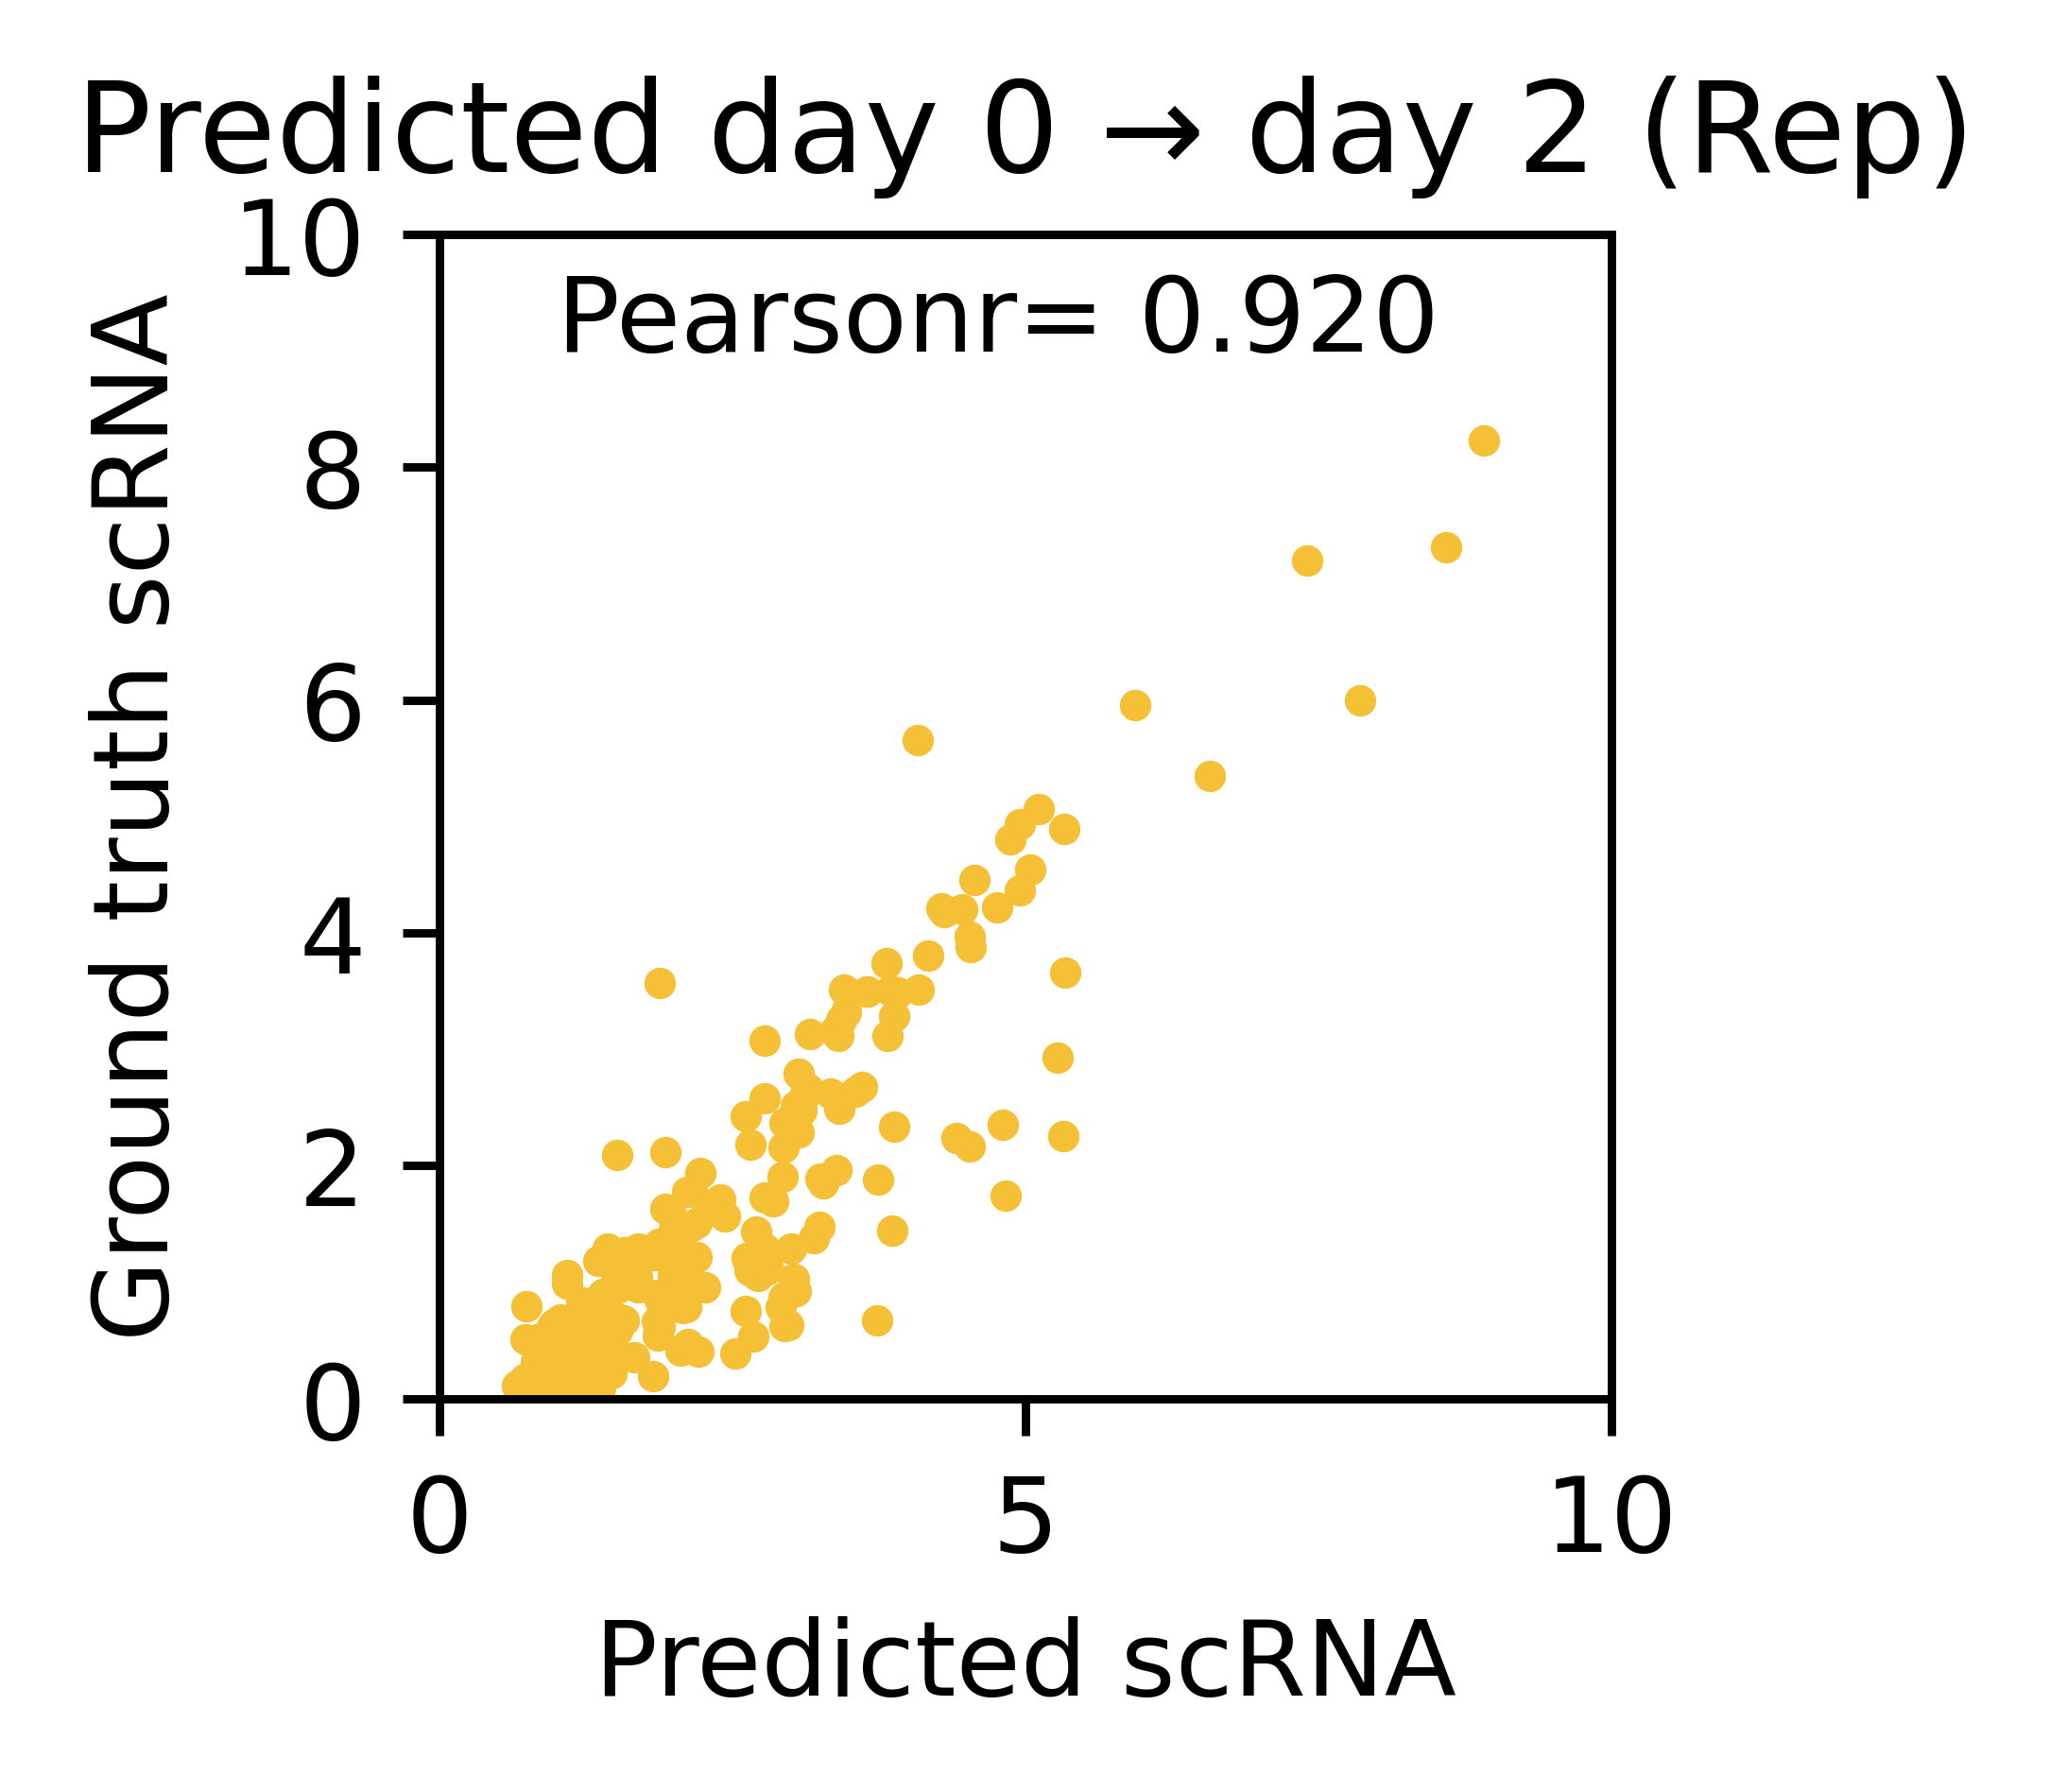

In [32]:
# d0 -> d2
plt.subplots(1,1,figsize=(2,2),dpi=800)
plt.scatter(sample_interp2.detach().cpu().mean(axis=0),
            test_adata[test_adata.obs['Group']==2].X.mean(axis=0),
            s=4,
            c='#f5bf36'
           )
plt.xlim([0,10])
plt.ylim([0,10])
plt.xlabel('Predicted scRNA')
plt.ylabel('Ground truth scRNA')
plt.title('Predicted day 0 → day 2 (Rep)')
sampler.cal_metric(sample_interp2, test_adata[test_adata.obs['Group']==2])
# add person correlation coefficient in the plot
r, p = pearsonr(sample_interp2.detach().cpu().mean(axis=0), test_adata[test_adata.obs['Group']==2].X.mean(axis=0))
plt.text(0.1, 0.9, f'Pearsonr= {r:.3f}', transform=plt.gca().transAxes)

Text(0.1, 0.9, 'Pearsonr= 0.856')

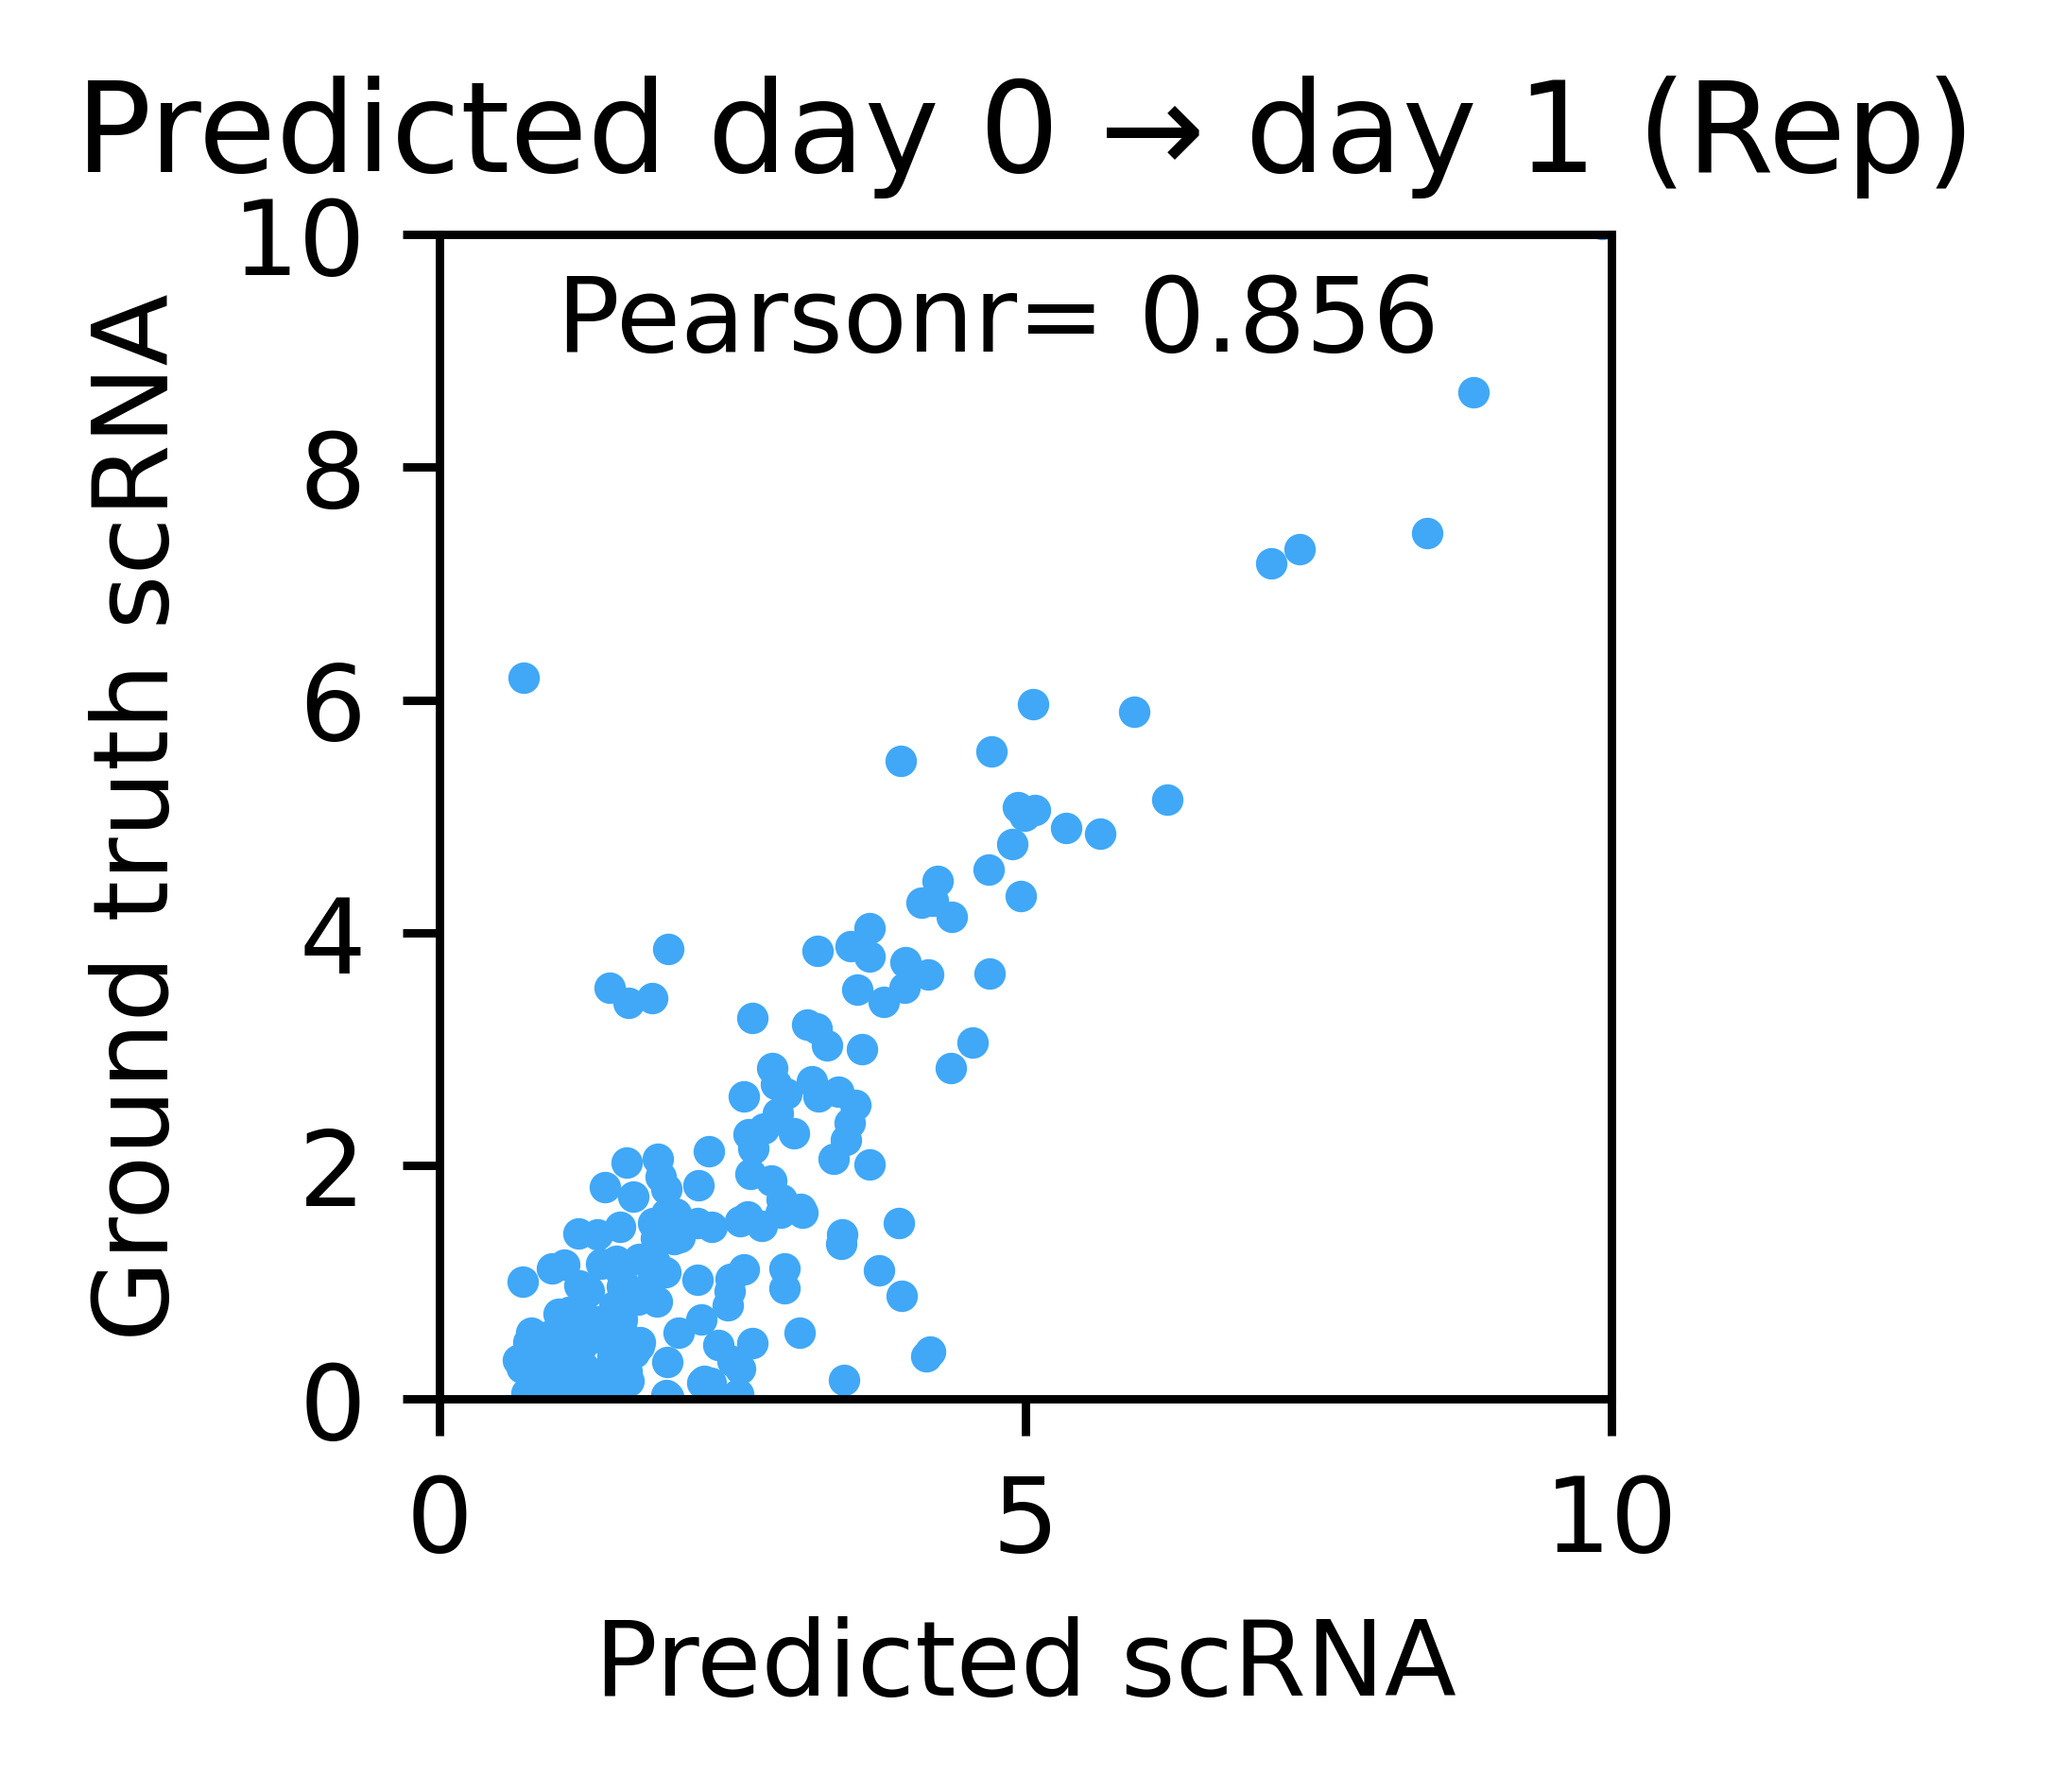

In [33]:
# d0 -> d1
plt.subplots(1,1,figsize=(2,2),dpi=800)
plt.scatter(sample_interp1.detach().cpu().mean(axis=0),
            test_adata[test_adata.obs['Group']==1].X.mean(axis=0),
            s=4,
            c='#40a8f7'
           )
plt.xlim([0,10])
plt.ylim([0,10])
plt.xlabel('Predicted scRNA')
plt.ylabel('Ground truth scRNA')
plt.title('Predicted day 0 → day 1 (Rep)')
sampler.cal_metric(sample_interp1, test_adata[test_adata.obs['Group']==1])
# add person correlation coefficient in the plot
r, p = pearsonr(sample_interp1.detach().cpu().mean(axis=0), test_adata[test_adata.obs['Group']==1].X.mean(axis=0))
plt.text(0.1, 0.9, f'Pearsonr= {r:.3f}', transform=plt.gca().transAxes)

Text(0.1, 0.9, 'Pearsonr= 0.998')

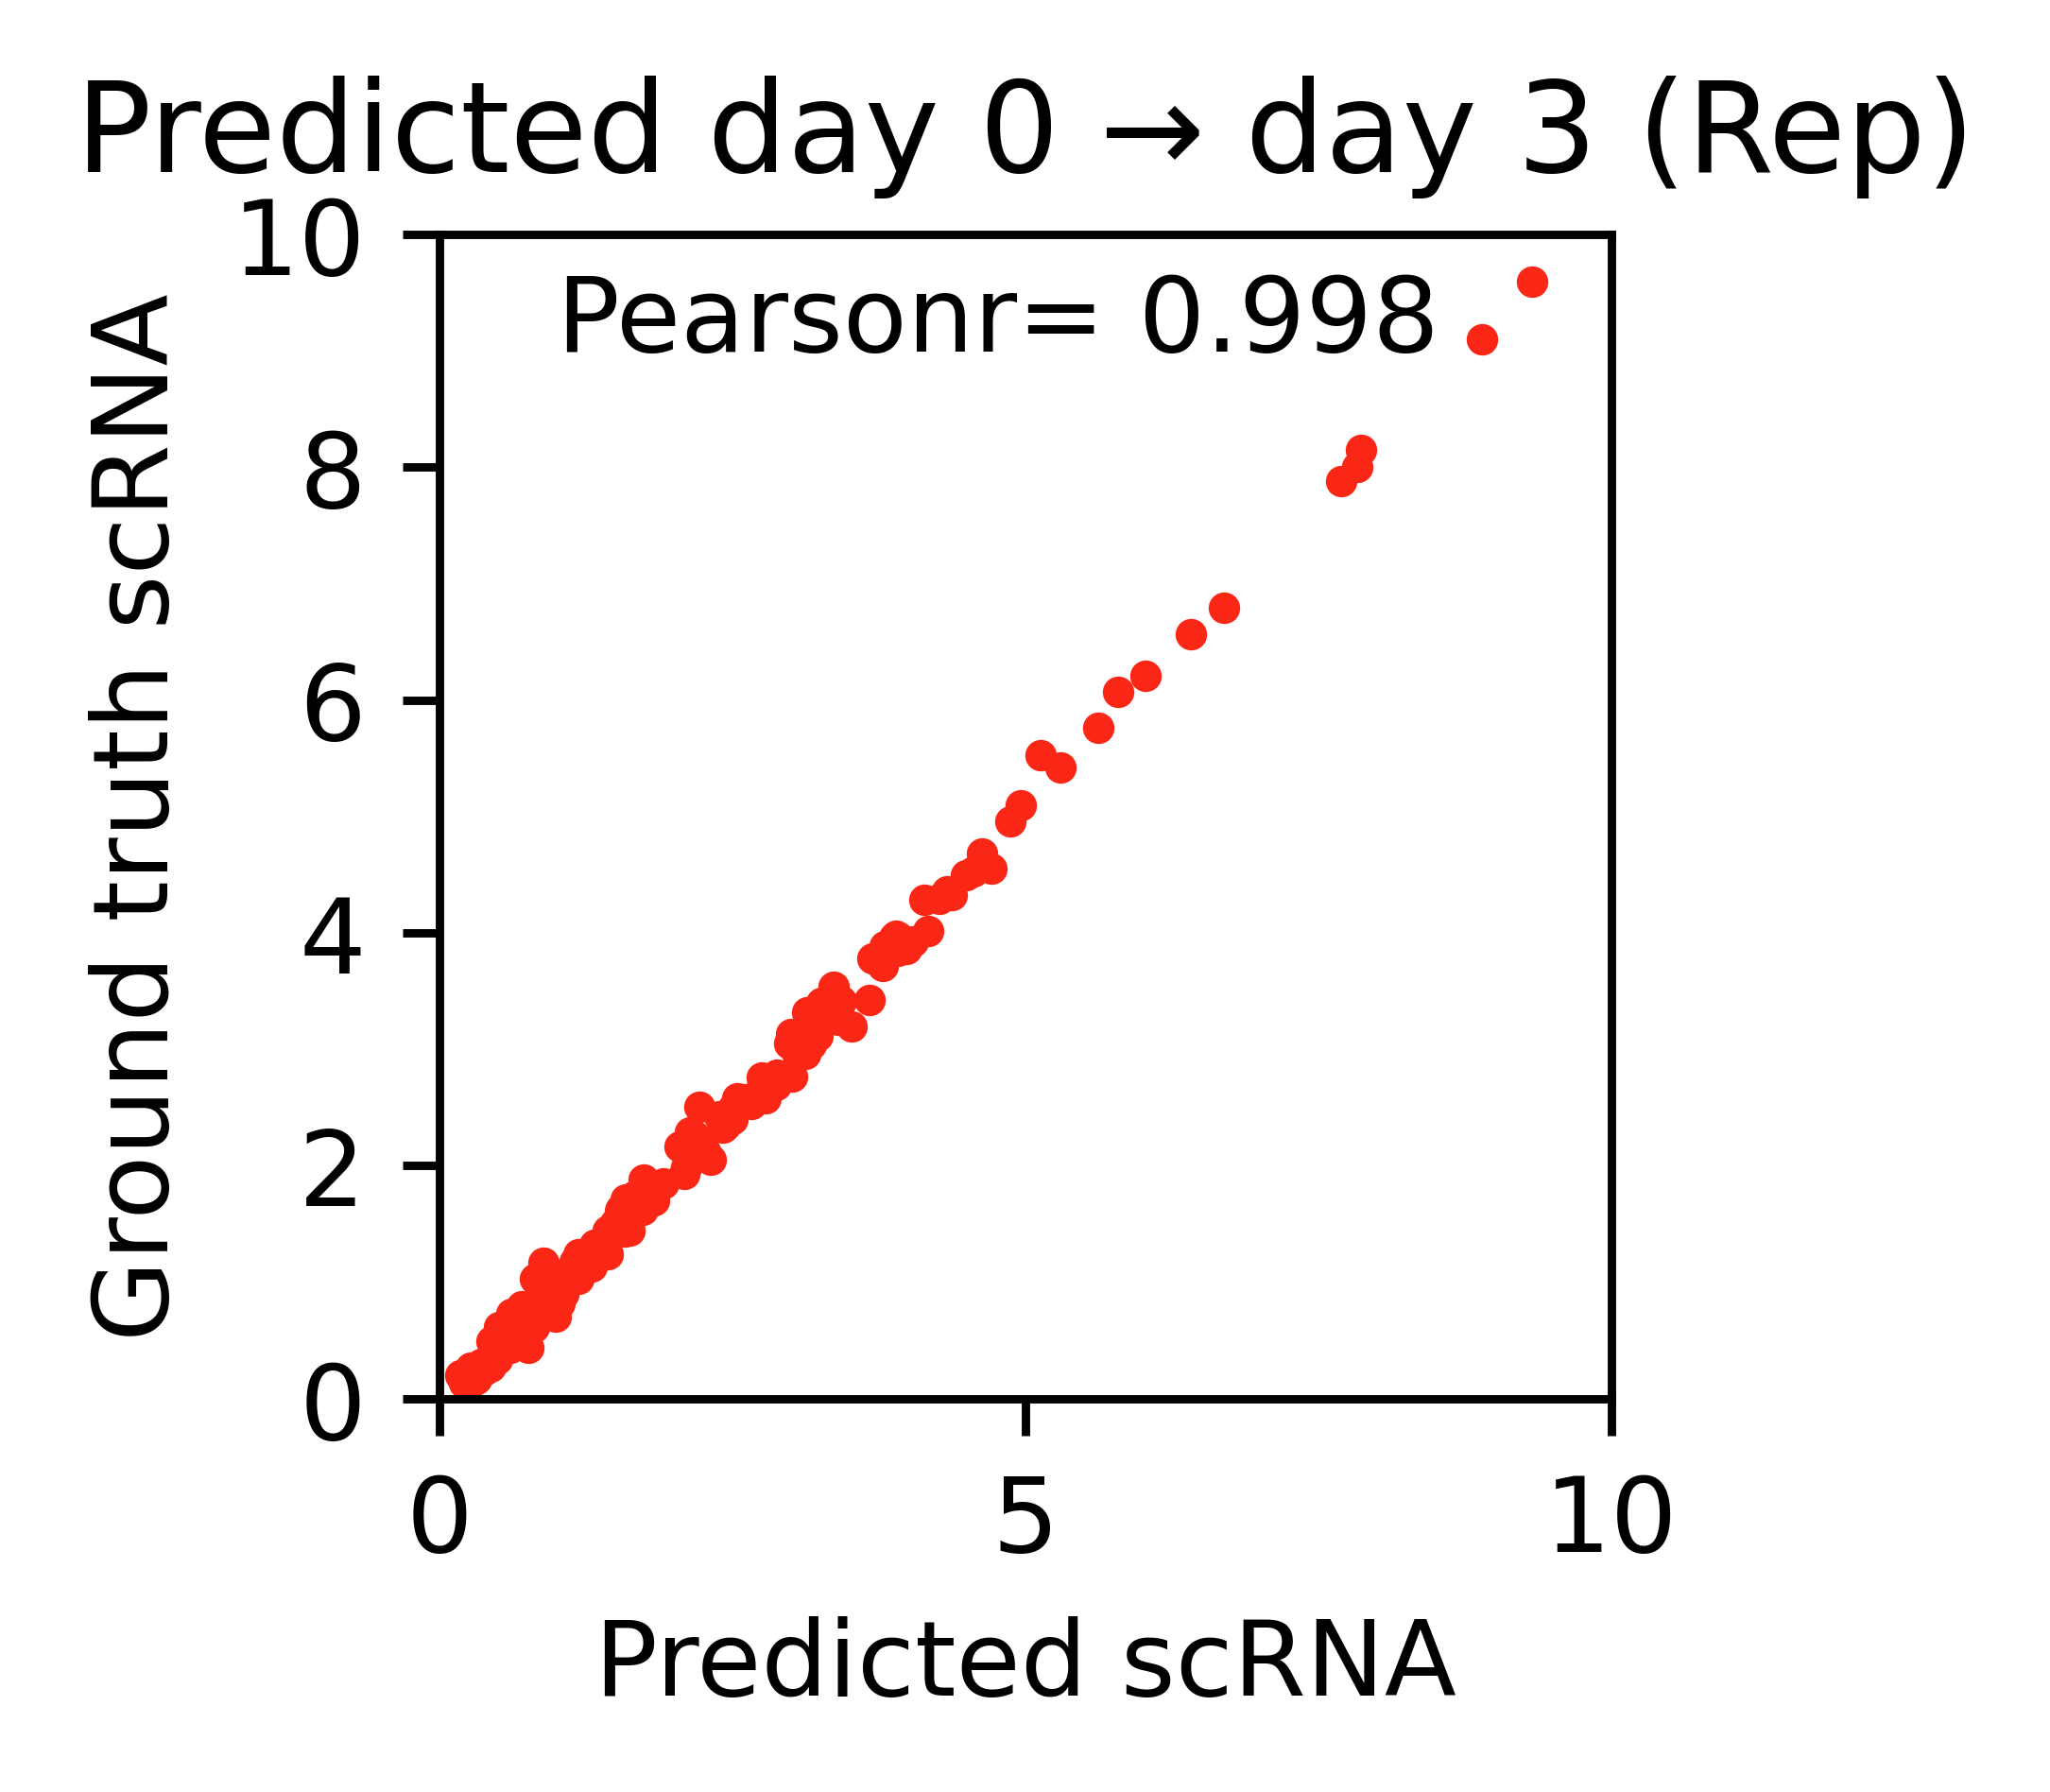

In [34]:
# d0 -> d3
plt.subplots(1,1,figsize=(2,2),dpi=800)
plt.scatter(sample_interp3.detach().cpu().mean(axis=0),
            test_adata[test_adata.obs['Group']==3].X.mean(axis=0),
            s=4,
            c='#fa2616'
           )
plt.xlim([0,10])
plt.ylim([0,10])
plt.xlabel('Predicted scRNA')
plt.ylabel('Ground truth scRNA')
plt.title('Predicted day 0 → day 3 (Rep)')
sampler.cal_metric(sample_interp3, test_adata[test_adata.obs['Group']==3])
# add person correlation coefficiente in the plot
r, p = pearsonr(sample_interp3.detach().cpu().mean(axis=0), test_adata[test_adata.obs['Group']==3].X.mean(axis=0))
plt.text(0.1, 0.9, f'Pearsonr= {r:.3f}', transform=plt.gca().transAxes)

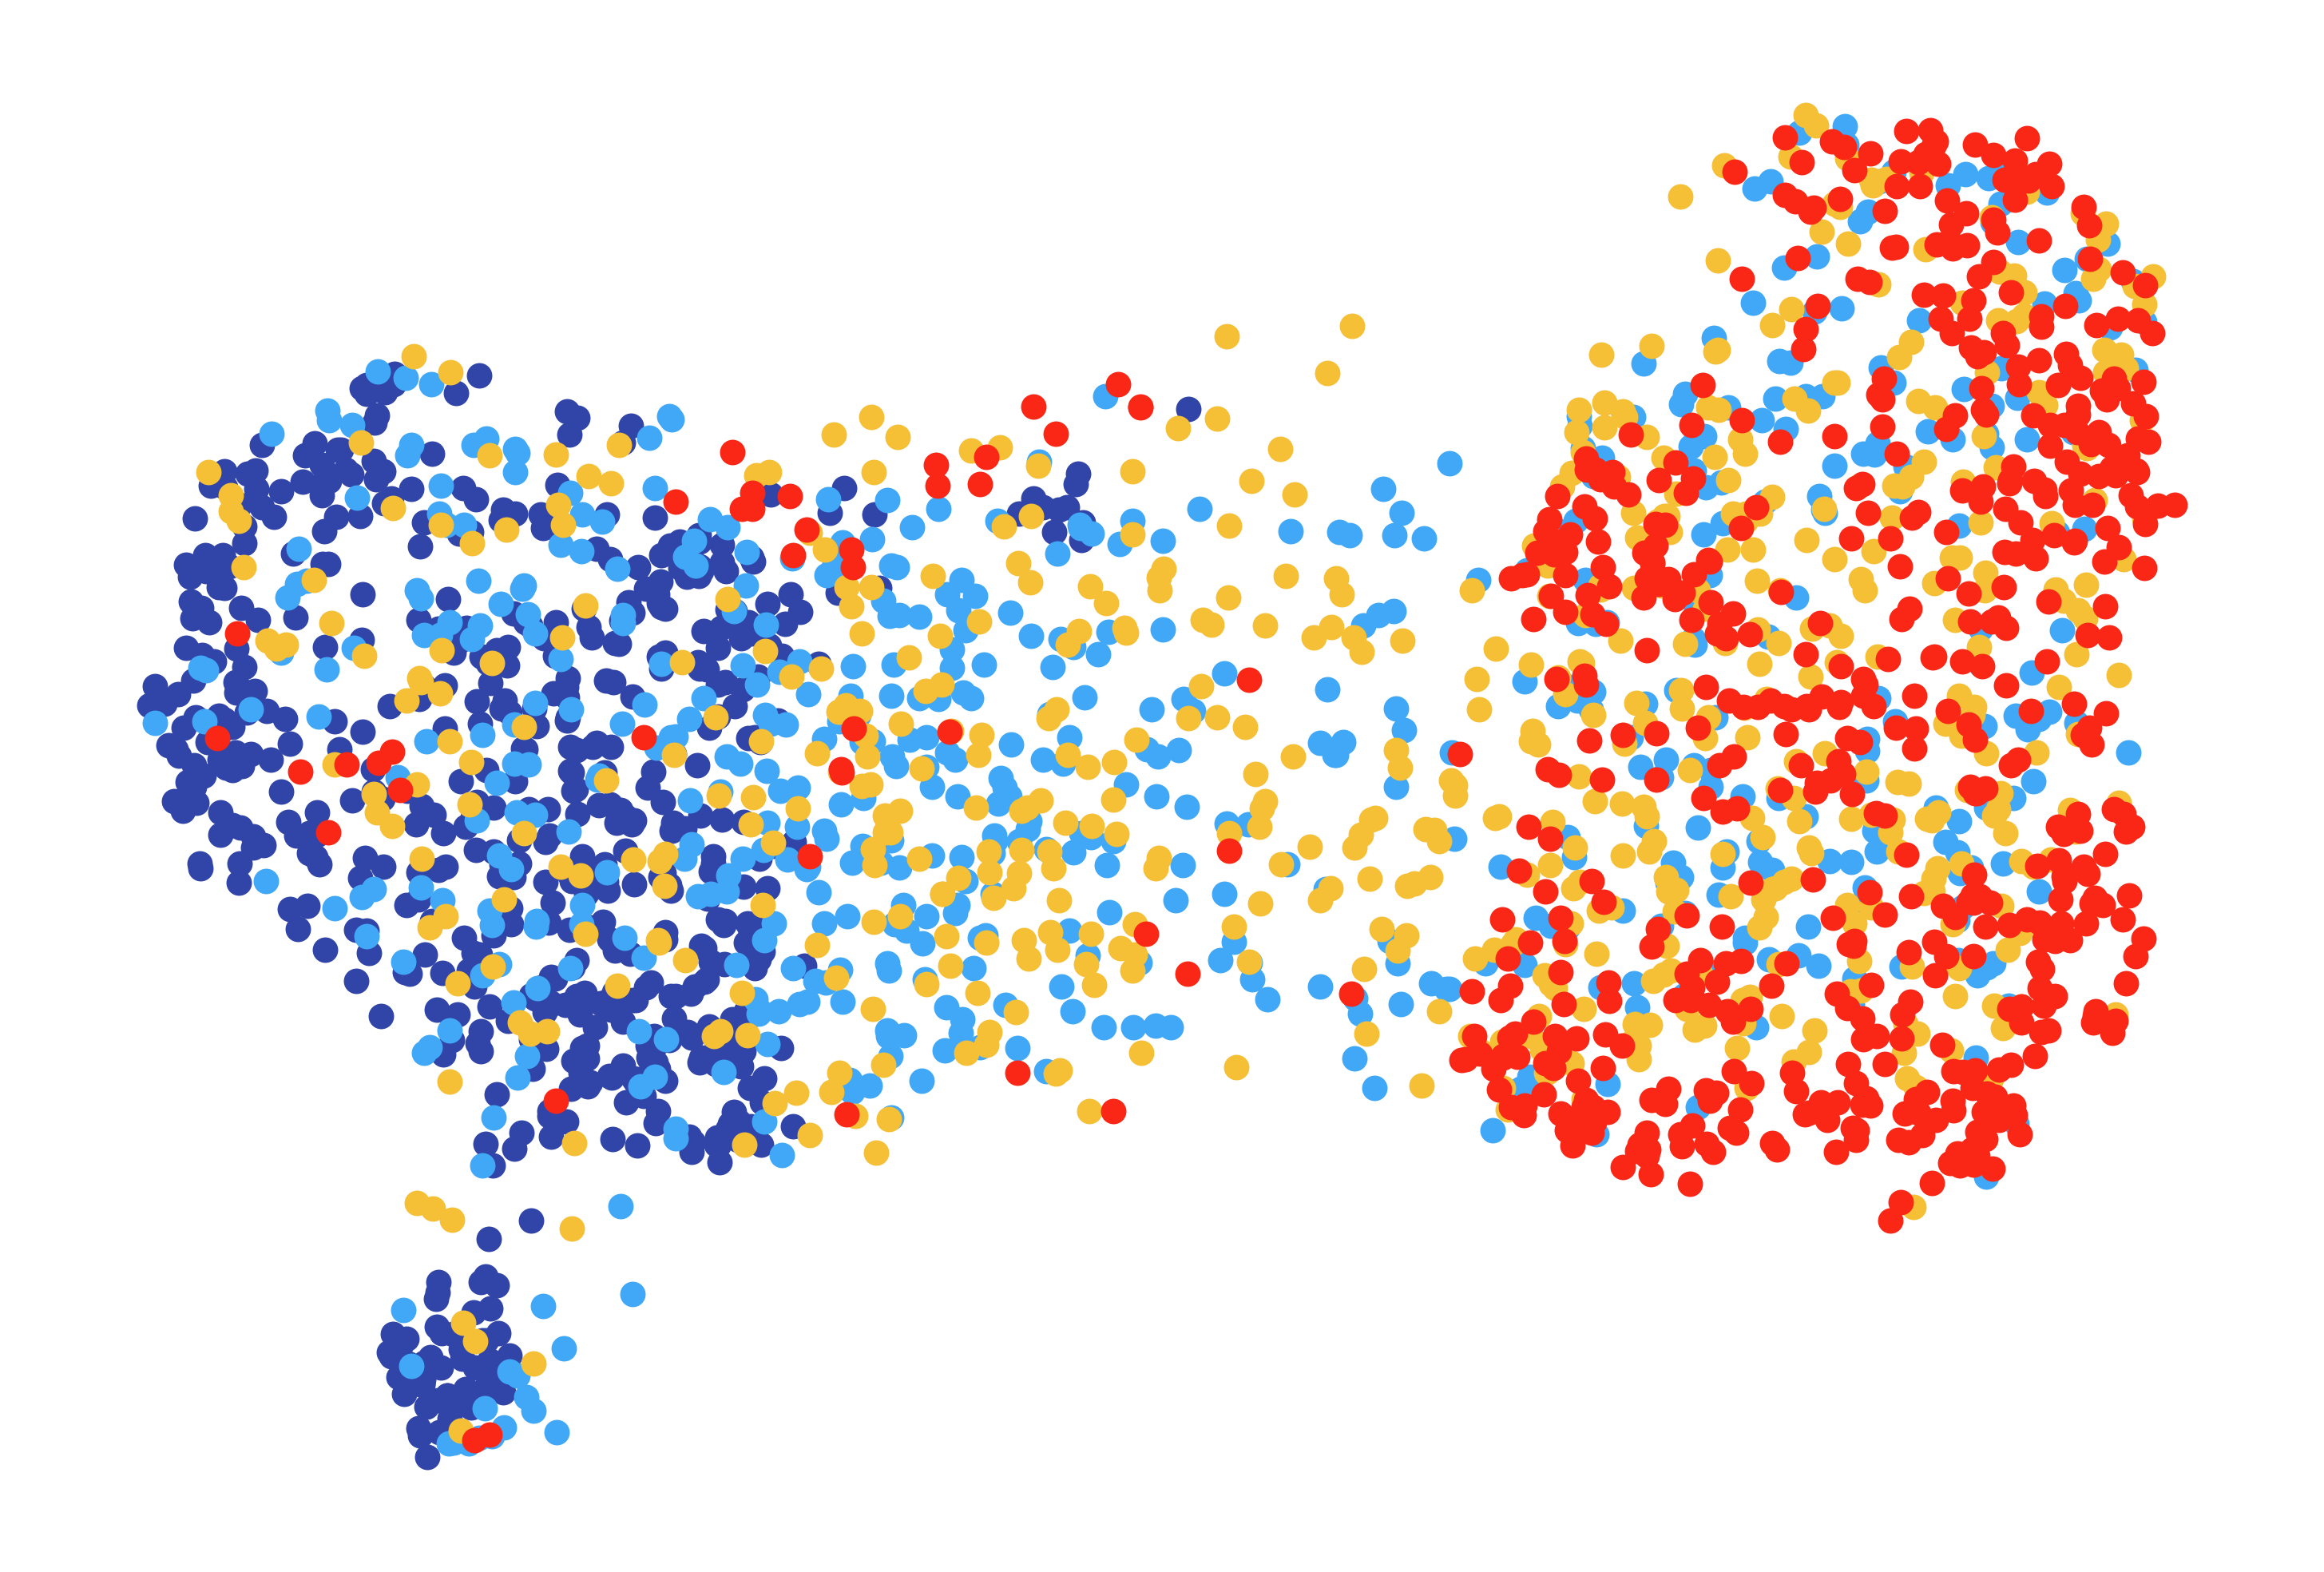

In [35]:
# Combine all points
from sklearn.decomposition import PCA
import umap
combined_points = np.concatenate([sample_interp0.detach().cpu().numpy(),
                                  sample_interp1.detach().cpu().numpy(),
                                  sample_interp2.detach().cpu().numpy(),
                                  sample_interp3.detach().cpu().numpy(),
                                 ], axis=0)
combined_labels  = np.array([0]*600+[1]*600+[2]*600+[3]*600)

pca = PCA(n_components=30)  # You can adjust the number of components
pca_result = pca.fit_transform(combined_points)
#pca_result

# Perform UMAP with increased neighbors
reducer = umap.UMAP(n_neighbors=50, min_dist=0.2, n_components=2)
embedding_combined = reducer.fit_transform(pca_result)

# Plotting
plt.figure(figsize=(6, 4), dpi=600)
colorlist = ['#3145a8', '#40a8f7', '#f5bf36', '#fa2616']  # Green and Magenta for interpolated points
for i in range(4):
    plt.scatter(embedding_combined[combined_labels == i, 0], 
                embedding_combined[combined_labels == i, 1], 
                c=colorlist[i], 
                s=8, 
                alpha=1)
plt.xlabel('UMAP 1')
plt.ylabel('UMAP 2')
plt.axis('off')
#plt.title('UMAP with Linear Interpolation between day0 and day3')
plt.show()


In [36]:
sampler.cal_metric(sample_interp0, test_adata[test_adata.obs['Group']==0])


(0.9982255915215392, 0.9993875281896607)

In [37]:
sampler.cal_metric(sample_interp1, test_adata[test_adata.obs['Group']==1])


(0.45764520294685507, 0.8562408462364051)

In [38]:
sampler.cal_metric(sample_interp2, test_adata[test_adata.obs['Group']==2])

(0.5801273027576603, 0.919677393344355)

In [39]:
sampler.cal_metric(sample_interp3, test_adata[test_adata.obs['Group']==3])

(0.9950081132227242, 0.9981971706790185)

In [40]:
pred_tensor =np.array( torch.cat([sample_interp0,sample_interp1,sample_interp2,sample_interp3], dim=0).detach().cpu())
all_new_data = anndata.AnnData(pred_tensor)
all_new_data.obs['weights'] = combined_labels
all_new_data.obs['weights'] = all_new_data.obs['weights'].astype(str).astype('category')
all_new_data.var_names = test_adata.var_names

sc.tl.rank_genes_groups(all_new_data, groupby='weights', method='wilcoxon')
all_new_data.layers['scaled'] = sc.pp.scale(all_new_data, copy=True).X
marker_genes_dict = {
    '0.0': ['T', 'GATA6','NANOG'],
}

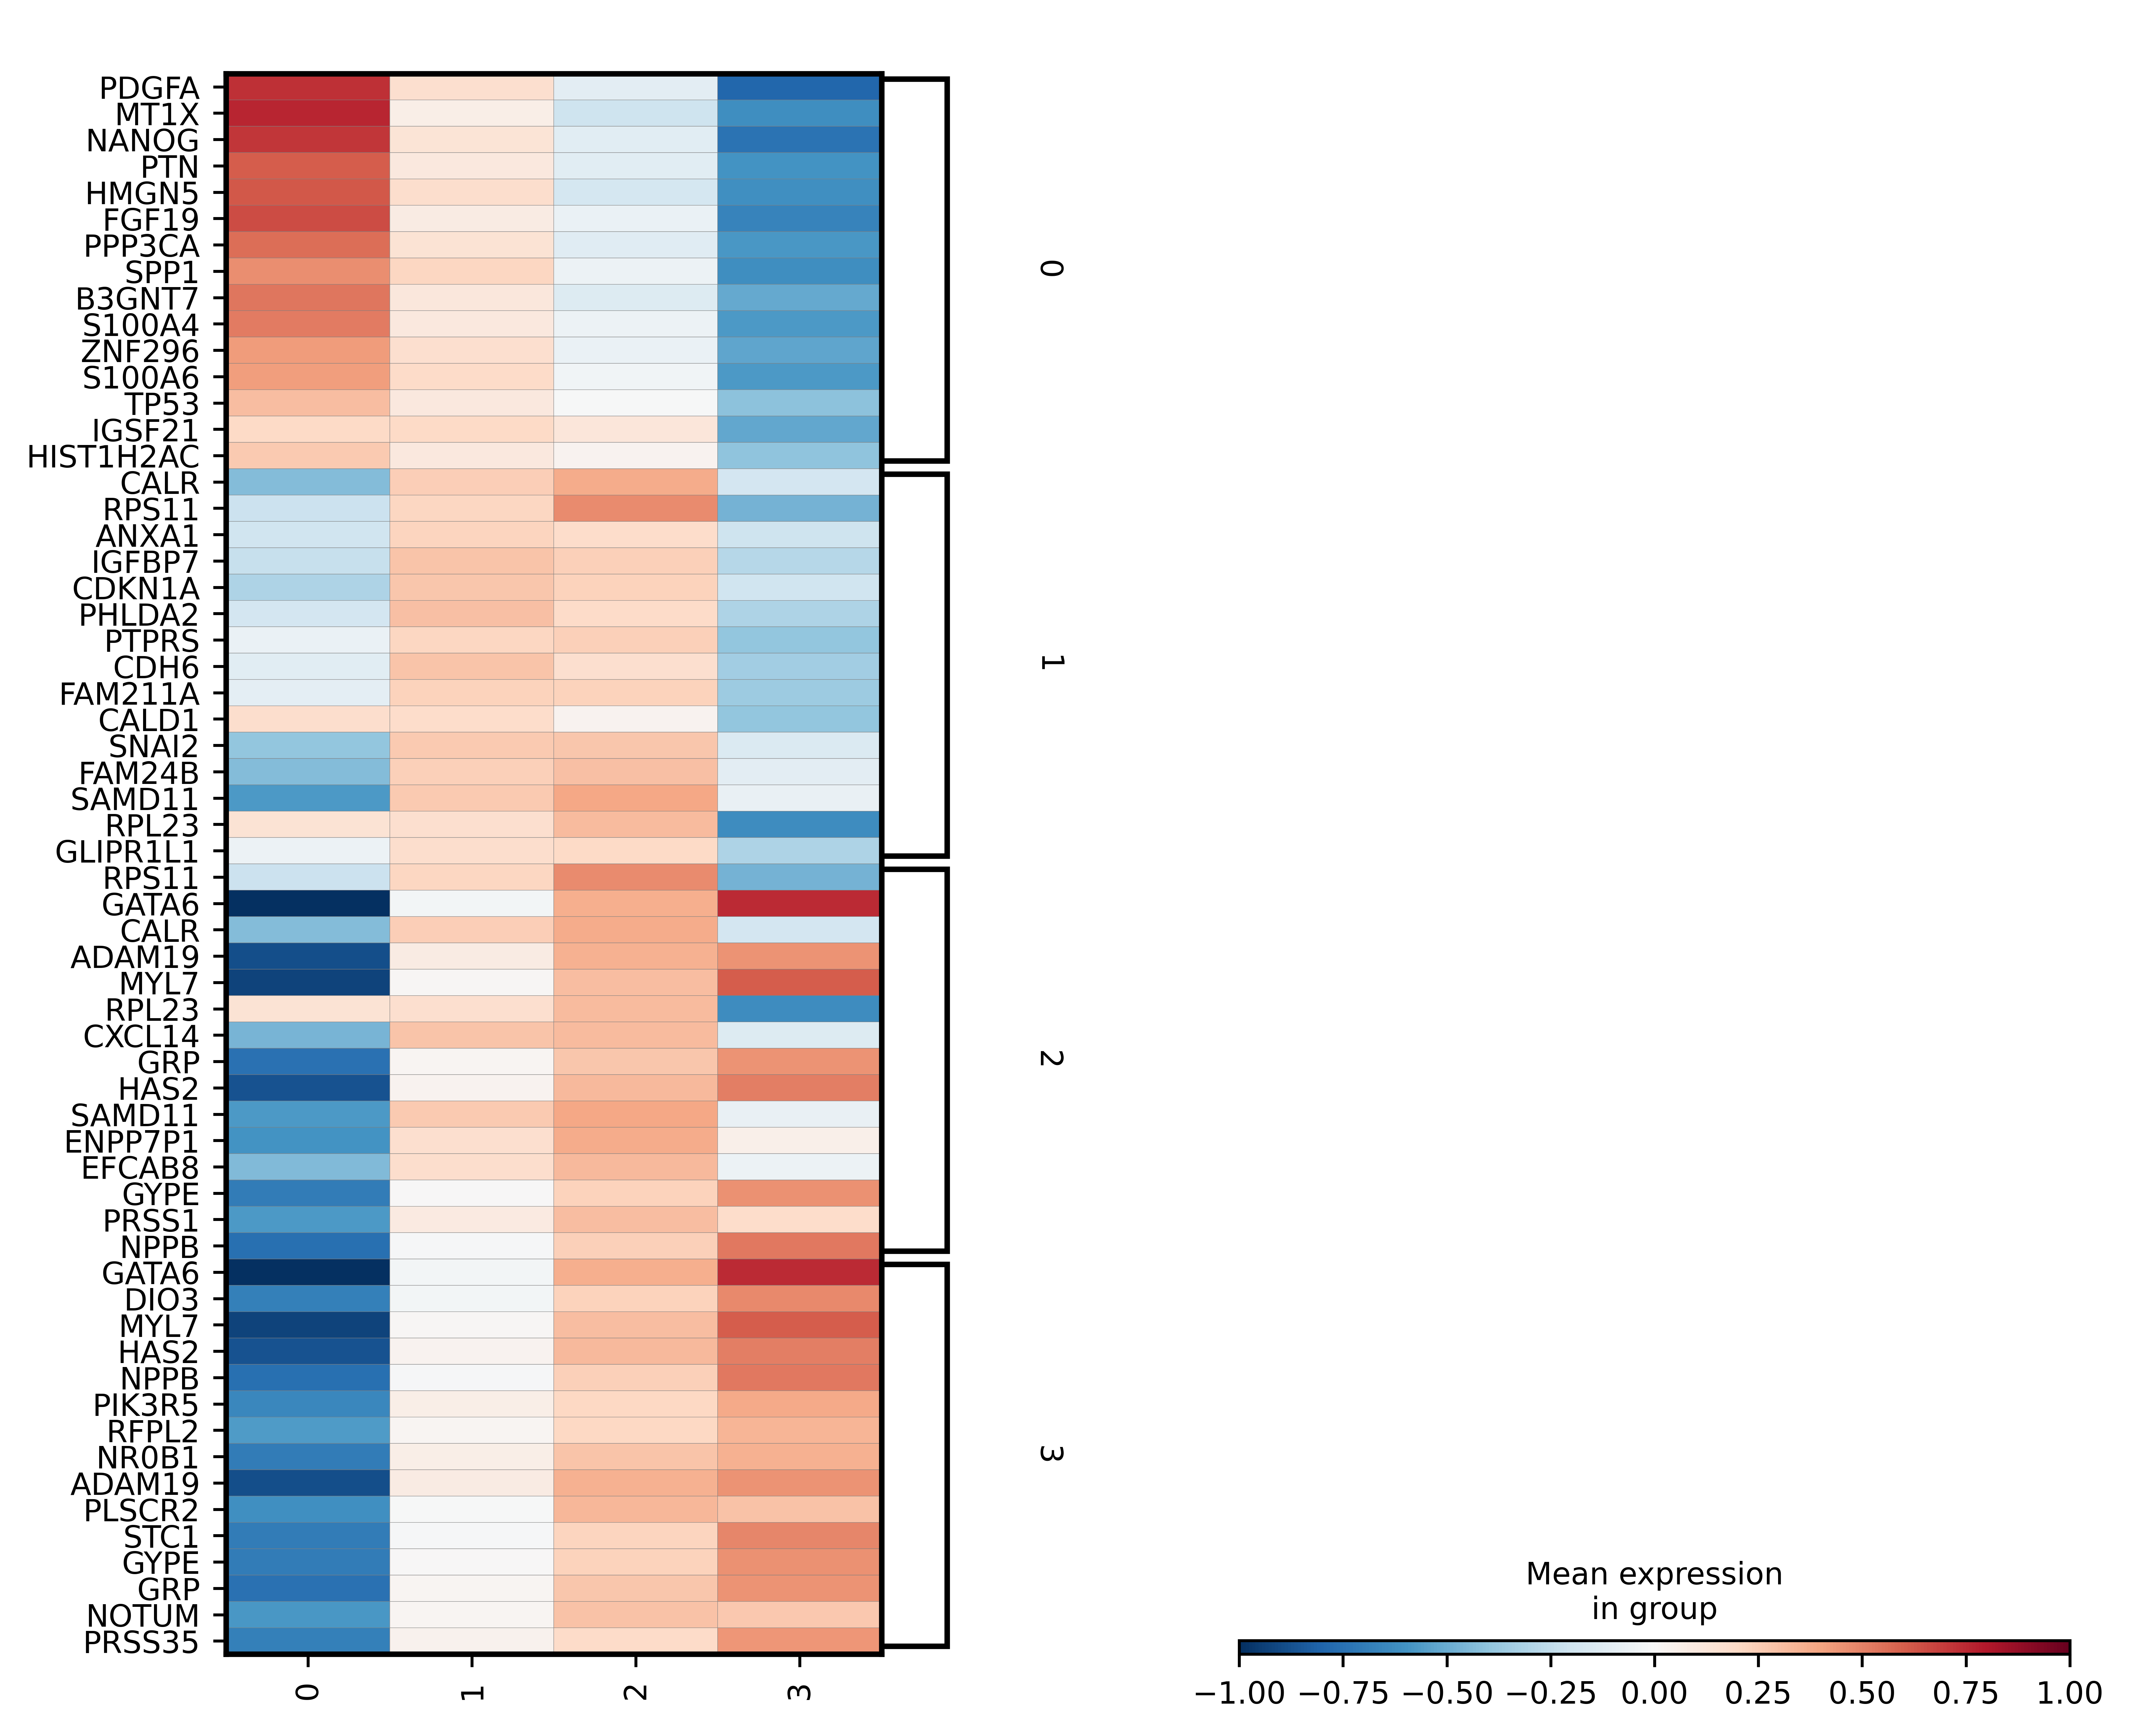

In [41]:
fig,ax = plt.subplots(figsize =(9,8),dpi=800)
sc.pl.rank_genes_groups_matrixplot(all_new_data, 
                                dendrogram=False,
                                n_genes=15, 
                                   use_raw=False, 
                                swap_axes=True, 
                                vmin=-1, vmax=1, 
                                cmap='RdBu_r', 
                                layer='scaled', 
                                   ax=ax,
                                show=True)

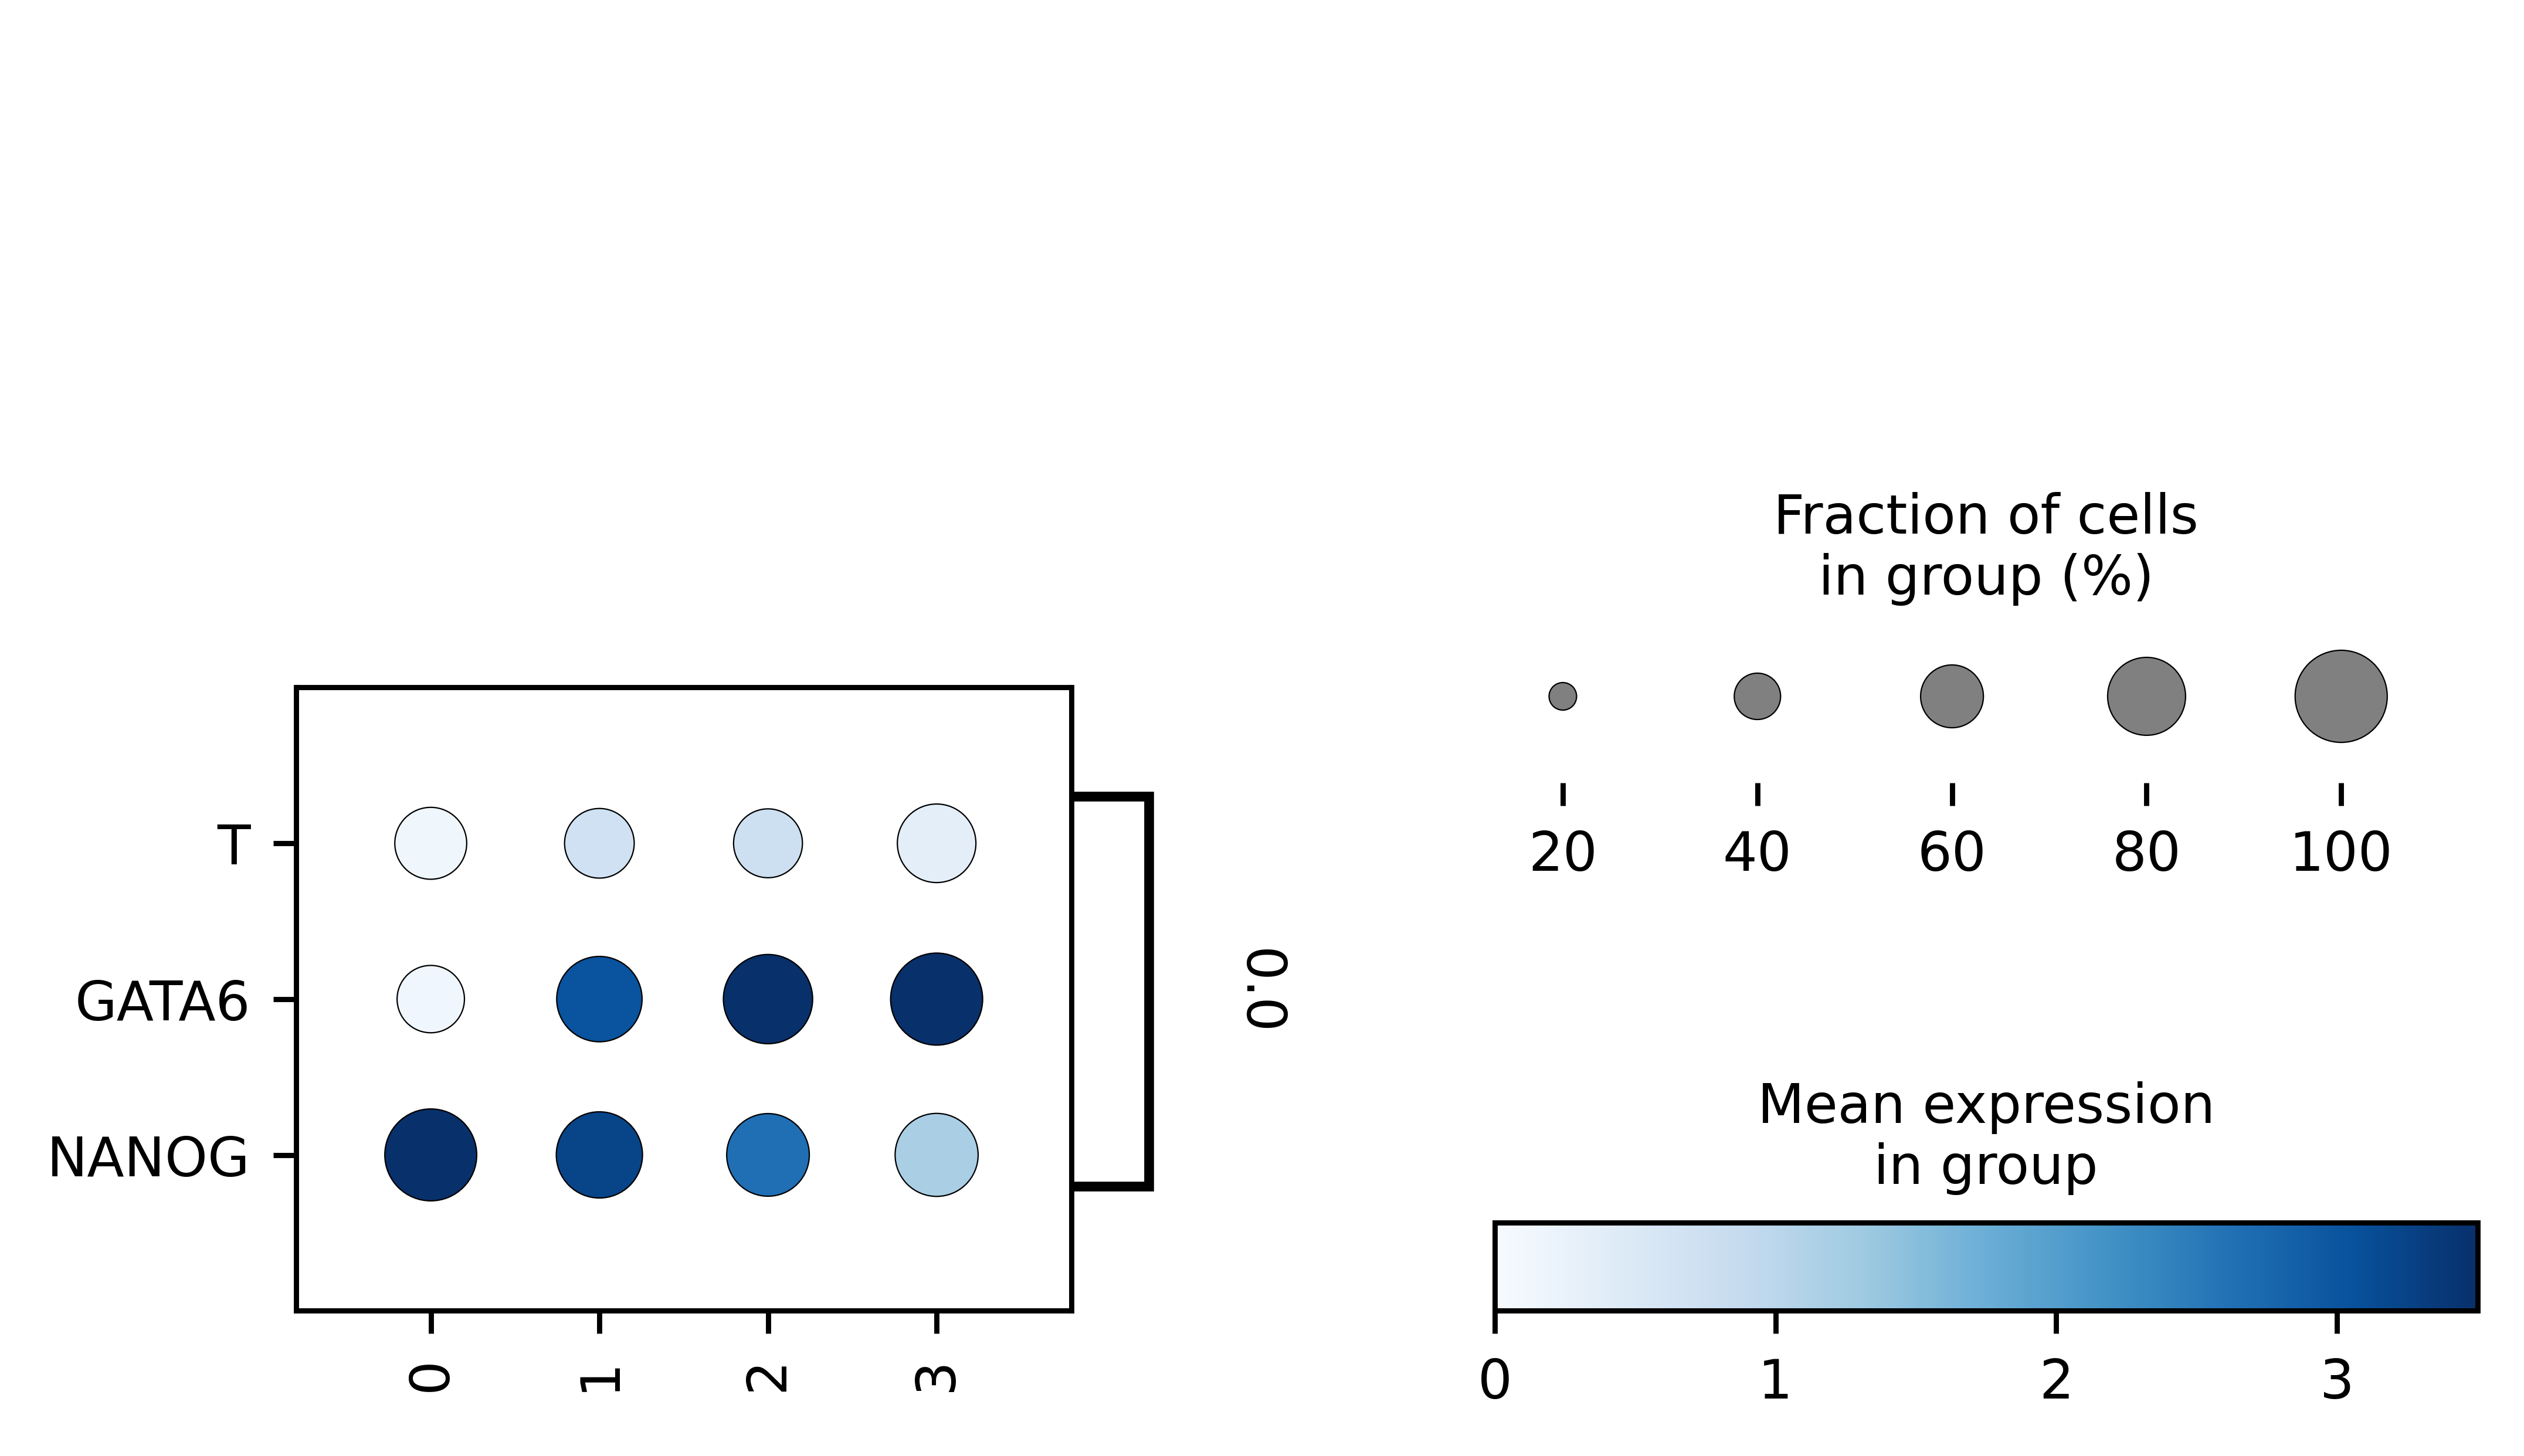

In [48]:
all_new_data.obs['weights'] = all_new_data.obs['weights'].cat.reorder_categories(
    ['0', '1', '2', '3']  # leftmost listed first
)

fig, ax = plt.subplots(figsize=(6, 3.5), dpi=800)  # swapped figsize
sc.pl.dotplot(all_new_data, 
              marker_genes_dict, 'weights', 
              vmin=0,
              vmax=3.5,
              dendrogram=False,
              swap_axes=True,
              ax=ax,
              cmap='Blues',
             )

In [ ]:
p_time = pd.read_csv('../Squidiff_project/figure2_dataset1_time_1022.csv',index_col=0)
all_new_data.obs['Pseudotime'] = p_time.values

In [ ]:
hex_colors = ['#3145a8', '#40a8f7', '#f5bf36','#fa2616']


plt.figure(figsize=(3,1
                   ),dpi=800)
sns.kdeplot(data=all_new_data.obs, 
            x="Pseudotime", 
            hue="weights", 
            bw_adjust=.8,
            palette=hex_colors,
            linewidth=2  ,  
            common_norm=False)
plt.legend().set_visible(False)
plt.xlabel("Pseudotime")
plt.ylabel("Density")
plt.xlim([0,1])
plt.show()